# Wildfire Burned Area Prediction
**Subject Code & Name**: ACE6313 Machine Learning Concepts and Technologies  
**Trimester**: March/April 2026 (T2610)  
**Students**: Lwee Tong Jun (ID: 1211112083) & Peng Ze Wei (ID: 1211108918)  
**UN SDG Alignment**: SDG 13 (Climate Action)  

This notebook implements the complete data preprocessing, visual exploration, machine learning model baseline training, PCA dimensionality reduction, and Random Forest hyperparameter optimization for wildfire burned area prediction.


### 1. Load Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error


### 2. Google Drive Mounting


In [2]:
# Mount Google Drive (for Google Colab execution environment)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = '/content/drive/MyDrive/Machine Learning/fire-occurence.csv'
except ImportError:
    # Local fallback
    file_path = 'fire-occurence.csv'

print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)
print(f"Initial Dataset Shape: {df.shape}")
df.head()


Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Machine Learning/fire-occurence.csv
Initial Dataset Shape: (23490, 38)


,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,58256,STAT,2000,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,...,Does Not Apply - Eastern OR,07/18/2000 07:00:00 PM,07/19/2000 01:20:00 PM,07/19/2000 01:15:00 PM,07/20/2000 12:50:00 AM,07/20/2000 09:13:00 AM,11/14/2000 09:16:00 AM,95,952,011
1,59312,STAT,2000,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,...,Does Not Apply - Eastern OR,08/24/2000 05:30:00 AM,08/24/2000 01:07:00 PM,08/24/2000 01:07:00 PM,09/01/2000 09:30:00 PM,08/29/2000 03:59:00 PM,12/21/2000 04:22:00 PM,97,971,024
2,61657,STAT,2001,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,...,Lvl 3 Restricted Shutdown,08/10/2001 05:40:00 PM,08/10/2001 05:47:00 PM,08/10/2001 05:45:00 PM,08/10/2001 06:30:00 PM,08/10/2001 06:42:00 PM,08/17/2001 11:45:00 AM,71,712,133
3,63735,STAT,2002,NOA,West Oregon,Philomath,02-551001-03,WREN,A,0.01,...,Lvl 1 Fire Season Only,07/06/2002 01:01:00 PM,07/06/2002 01:04:00 PM,07/06/2002 01:02:00 PM,07/06/2002 01:07:00 PM,07/07/2002 09:16:00 AM,07/28/2002 10:08:00 AM,55,551,001
4,68019,STAT,2003,NOA,West Oregon,Dallas,03-552013-04,Ritner Creek,A,0.01,...,Lvl 3 Restricted Shutdown,08/22/2003 04:00:00 AM,08/22/2003 05:00:00 AM,08/22/2003 05:00:00 AM,08/22/2003 09:30:00 AM,08/22/2003 04:12:00 PM,09/04/2003 09:39:00 AM,55,552,013


### 3. Data Preprocessing & Leakage Prevention
We drop unique metadata columns, target leakage columns (`Size_class` and `Control_DateTime`), handle missing values, and extract seasonal/diurnal features.


In [3]:
# Define target leakage and metadata columns to drop
leakage_columns = ['Size_class', 'Control_DateTime']
useless_columns = [
    'Serial', 'FullFireNumber', 'FireName', 'Cause_Comments',
    'LandmarkLocation', 'DistrictCode', 'UnitCode', 'DistFireNumber',
    'CreationDate', 'ModifiedDate'
]
df = df.drop(columns=leakage_columns + useless_columns, errors='ignore')

# Handle missing values in target and parse datetime
df = df.dropna(subset=['EstTotalAcres'])
df['Ign_DateTime'] = pd.to_datetime(df['Ign_DateTime'], errors='coerce')
df = df.dropna(subset=['Ign_DateTime'])

# Feature Engineering: Extract Month and Hour
df['Ign_Month'] = df['Ign_DateTime'].dt.month
df['Ign_Hour'] = df['Ign_DateTime'].dt.hour

# Drop parsed datetime columns and drop remaining NaN rows
time_columns_to_drop = ['Ign_DateTime', 'ReportDateTime', 'Discover_DateTime']
df = df.drop(columns=time_columns_to_drop, errors='ignore')
df = df.dropna()

print(f"Cleaned Dataset Shape: {df.shape}")
df.info()


/tmp/ipykernel_1450/3613975062.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ign_DateTime'] = pd.to_datetime(df['Ign_DateTime'], errors='coerce')


Cleaned Dataset Shape: (23202, 25)
<class 'pandas.core.frame.DataFrame'>
Index: 23202 entries, 0 to 23489
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   FireCategory            23202 non-null  object 
 1   FireYear                23202 non-null  int64  
 2   Area                    23202 non-null  object 
 3   DistrictName            23202 non-null  object 
 4   UnitName                23202 non-null  object 
 5   EstTotalAcres           23202 non-null  float64
 6   Protected_Acres         23202 non-null  float64
 7   HumanOrLightning        23202 non-null  object 
 8   CauseBy                 23202 non-null  object 
 9   GeneralCause            23202 non-null  object 
 10  SpecificCause           23202 non-null  object 
 11  Lat_DD                  23202 non-null  float64
 12  Long_DD                 23202 non-null  float64
 13  LatLongDD               23202 non-null  object 
 14  FO_LandO

### 4. Visual Exploration: Target Skewness
We plot the log-transformed distribution of the target variable `EstTotalAcres` using a local variable to prevent target leakage into the feature space.


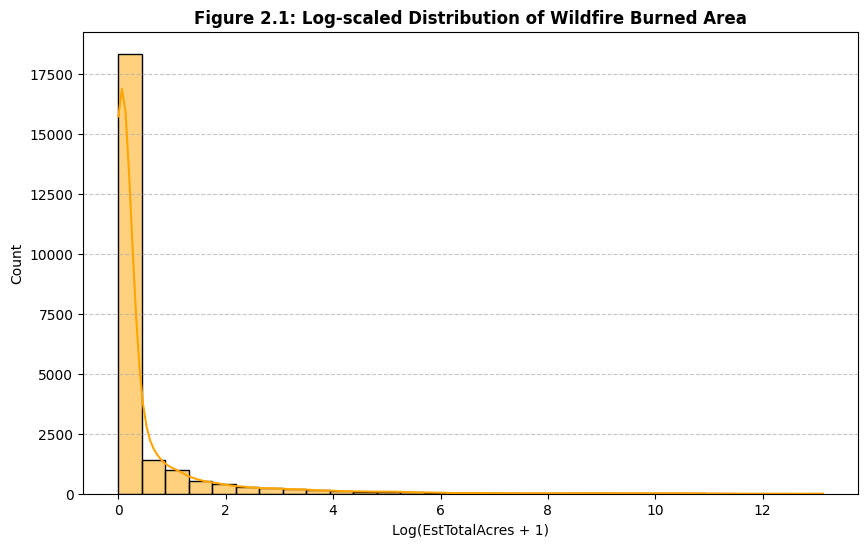

In [4]:
plt.figure(figsize=(10, 6))

# Plot the distribution on a log scale (using np.log1p locally to avoid leakage)
log_burned_area = np.log1p(df['EstTotalAcres'])
sns.histplot(x=log_burned_area, kde=True, color='orange', bins=30)

plt.title('Figure 2.1: Log-scaled Distribution of Wildfire Burned Area', fontsize=12, fontweight='bold')
plt.xlabel('Log(EstTotalAcres + 1)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save image in workspace
plt.savefig('Distribution of Burned Area.png', dpi=300)
plt.show()


### 5. Categorical Feature Encoding
Instead of one-hot encoding (which would expand features to 23,463 dimensions), category codes are applied to retain a compact 24-feature space.


In [5]:
# Convert object columns to category codes (Label Encoding)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

print("Encoding complete. Columns types:")
print(df.dtypes.value_counts())
df.head()


Encoding complete. Columns types:
int8       15
float64     5
int16       2
int32       2
int64       1
Name: count, dtype: int64


,FireCategory,FireYear,Area,DistrictName,UnitName,EstTotalAcres,Protected_Acres,HumanOrLightning,CauseBy,GeneralCause,...,Twn,Rng,Sec,Subdiv,County,RegUseZone,RegUseRestriction,Industrial_Restriction,Ign_Month,Ign_Hour
0,0,2000,0,1,14,0.75,0.75,1,3,4,...,14,67,31.0,7,11,24,4,0,7,19
1,0,2000,0,7,16,80.00,80.00,1,3,4,...,10,79,32.0,7,30,49,4,0,8,5
2,0,2001,2,9,13,0.10,0.10,0,5,8,...,71,7,7.0,16,14,75,4,3,8,17
3,0,2002,1,12,21,0.01,0.01,0,5,7,...,21,13,28.0,15,1,85,1,1,7,13
4,0,2003,1,12,9,0.01,0.01,1,3,4,...,18,21,36.0,22,27,99,4,3,8,4


### 6. Train-Test Split and Standardization


In [6]:
# Define target and features
X = df.drop(columns=['EstTotalAcres'])
y = df['EstTotalAcres']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")


Training set shape: (18561, 24)
Testing set shape: (4641, 24)


### 7. Baseline Models (Standard Features)
We train and evaluate 6 algorithms: Linear Regression, kNN, Decision Trees, Random Forest, Gradient Boosting, and MLP.


In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'MLP (Neural Net)': MLPRegressor(max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

performance_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
display(performance_df)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,RMSE,R2
3,Random Forest,6951.772270,0.122049
0,Linear Regression,7451.702199,-0.008766
5,MLP (Neural Net),7481.416797,-0.016827
1,KNN,7523.835403,-0.028390
4,Gradient Boosting,7572.924309,-0.041853
2,Decision Tree,10985.276140,-1.192306


### 8. Dimensionality Reduction (PCA)
We apply PCA to capture 95% of explained variance, reducing features to 18 components, and retrain our baseline models.


In [8]:
# Apply PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    predictions = model.predict(X_test_pca)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    pca_results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

pca_performance_df = pd.DataFrame(pca_results).sort_values(by='R2', ascending=False)
print(f"Reduced feature space to {X_train_pca.shape[1]} components")
display(pca_performance_df)


Reduced feature space to 18 components


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,RMSE,R2
0,Linear Regression,7453.311852,-0.009202
5,MLP (Neural Net),7465.645695,-0.012544
4,Gradient Boosting,7472.473235,-0.014397
1,KNN,7544.986707,-0.034180
3,Random Forest,7725.049268,-0.084131
2,Decision Tree,8172.007573,-0.213212


### 9. Plotting PCA explained variance curve


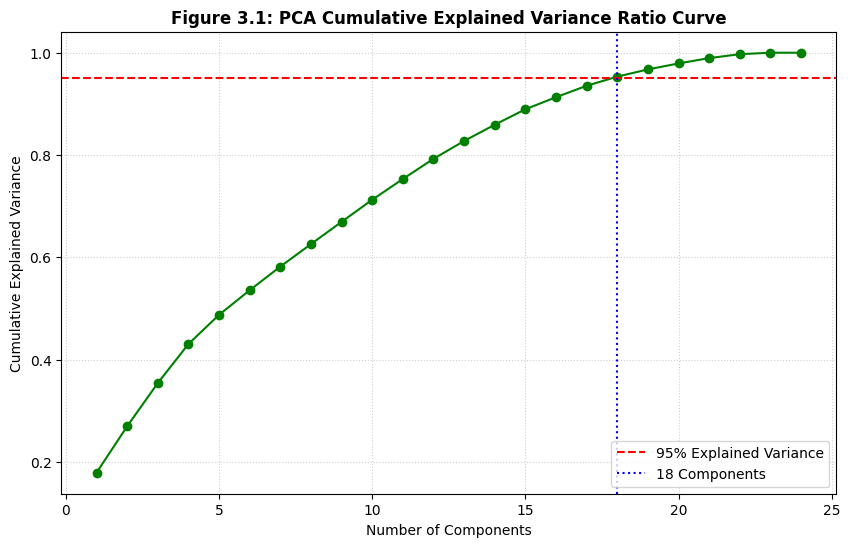

In [9]:
# Calculate cumulative variance
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='g')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=18, color='b', linestyle=':', label='18 Components')

plt.title('Figure 3.1: PCA Cumulative Explained Variance Ratio Curve', fontsize=12, fontweight='bold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('PCA Cumulative Explained Variance Ratio curve.png', dpi=300)
plt.show()


### 10. Model Optimization: Random Forest
Tuning `n_estimators` with values `[50, 100, 150]` to find the optimal ensemble size.


In [10]:
tree_options = [50, 100, 150]
tuned_r2_scores = []
best_r2 = -float('inf')
best_n = 0

print("Testing different Random Forest configurations...")
for n in tree_options:
    temp_model = RandomForestRegressor(n_estimators=n, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    temp_preds = temp_model.predict(X_test_scaled)
    temp_r2 = r2_score(y_test, temp_preds)
    tuned_r2_scores.append(temp_r2)
    print(f"Trees: {n}, R2 Score: {temp_r2:.4f}")

    if temp_r2 > best_r2:
        best_r2 = temp_r2
        best_n = n

print(f"\nBest configuration: {best_n} trees with R2 of {best_r2:.4f}")

# Train the best model
best_rf = RandomForestRegressor(n_estimators=best_n, random_state=42)
best_rf.fit(X_train_scaled, y_train)


Testing different Random Forest configurations...
Trees: 50, R2 Score: 0.1367
Trees: 100, R2 Score: 0.1220
Trees: 150, R2 Score: 0.1490

Best configuration: 150 trees with R2 of 0.1490


RandomForestRegressor(n_estimators=150, random_state=42)

### 11. Plotting RF Tuning curve


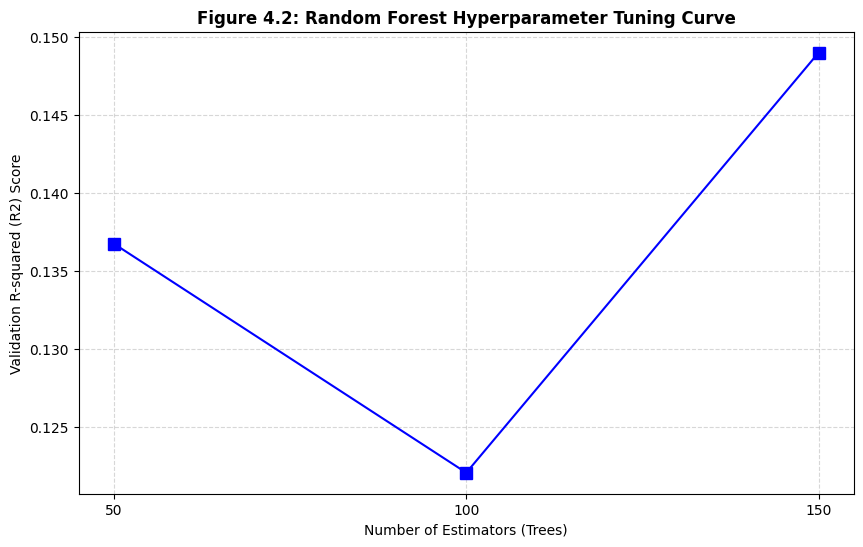

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(tree_options, tuned_r2_scores, marker='s', linestyle='-', color='b', markersize=8)

plt.title('Figure 4.2: Random Forest Hyperparameter Tuning Curve', fontsize=12, fontweight='bold')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Validation R-squared (R2) Score')
plt.xticks(tree_options)
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Random Forest Tuning Curve.png', dpi=300)
plt.show()


### 12. Final Model Evaluation and Summary


In [12]:
y_final_pred = best_rf.predict(X_test_scaled)
final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

summary_data = {
    'Metric': ['Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Optimized Random Forest Value': [final_rmse, final_r2]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

initial_best_r2 = performance_df['R2'].max()
print(f"\nImprovement over baseline R2: {final_r2 - initial_best_r2:.4f}")


,Metric,Optimized Random Forest Value
0,Root Mean Squared Error (RMSE),6844.214304
1,R-squared (R2),0.149006



Improvement over baseline R2: 0.0270
